In [2]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from trees.causal_forest import CF

K = 5
w = 0.6
N = 10000
iterations = 10
n_estimators= [500,2000]

cols = ['condition', 'cate', 'distance', 'T0', 'T1', 'depth', 'norm_cate',
       'score','algorithm', 'n_estimators']

scores = pd.DataFrame(columns=cols)


for exp in tqdm(range(iterations)):
    data = Data()
    data.generate(n=N, seed=exp)
    data.generate_random_condition()
    for n in n_estimators:
        cf = CF(data)
        cf.fit(criterion='mse', n_estimators=n)
        cf.parse_forest()
        cf_scores = cf.get_topK(k=K,w = w, print_summaries=False)
        cf_scores['n_estimators'] = n
        scores=pd.concat([scores, cf_scores], ignore_index=True)
        

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


100%|██████████| 10/10 [40:43<00:00, 244.37s/it]


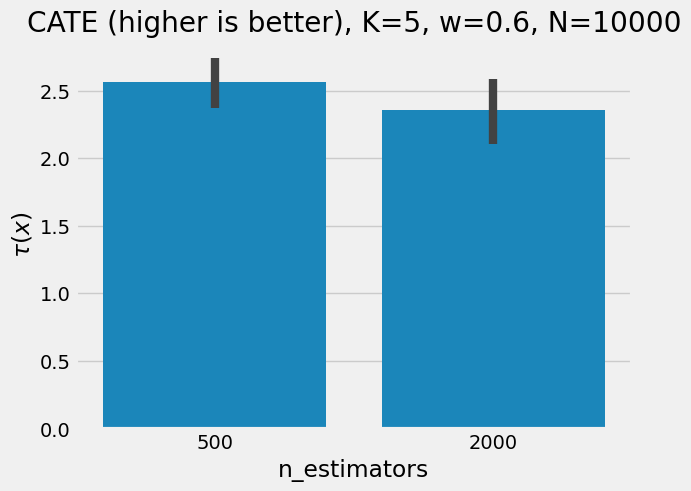

In [3]:
sns.barplot(x='n_estimators', y='t', data=scores)
plt.title(f"CATE (higher is better), K={str(K)}, w={str(w)}, N={str(N)}")
plt.ylabel(r"$\tau(x)$")
plt.show()

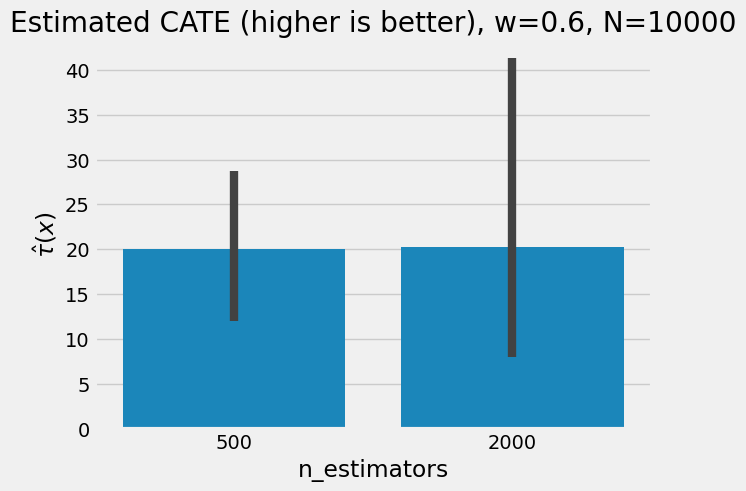

In [4]:
sns.barplot(x='n_estimators', y='t_est', data=scores)
plt.title(fr"Estimated CATE (higher is better), w={str(w)}, N={str(N)}")
plt.ylabel(r"$\hat{{\tau}}(x)$")
plt.show()

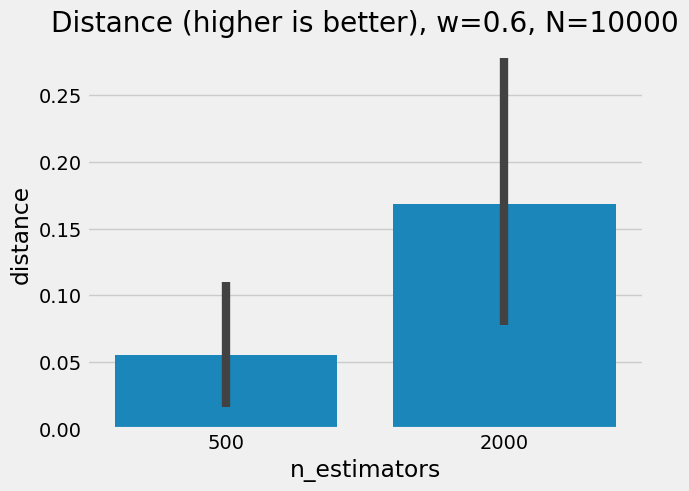

In [5]:
sns.barplot(x='n_estimators', y='distance', data=scores)
plt.title(f"Distance (higher is better), w={str(w)}, N={str(N)}")
plt.show()

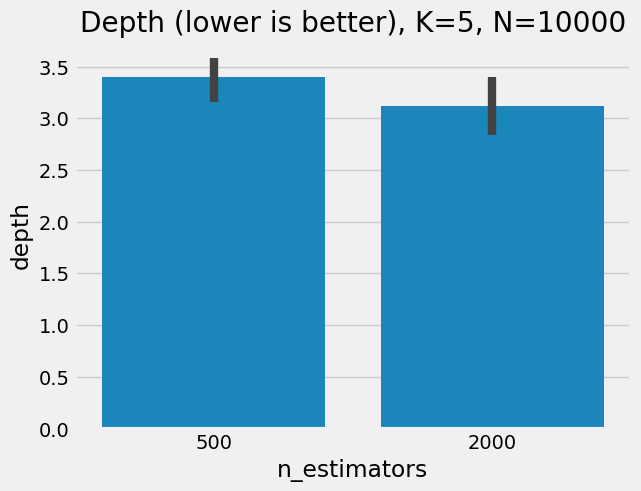

In [6]:
sns.barplot(x='n_estimators', y='depth', data=scores)
plt.title(f"Depth (lower is better), K={str(K)}, N={str(N)}")
plt.show()